# 01 — Análisis Exploratorio de Datos (EDA)
**Equipo:** HEREDIA SARAVIA EDWIN · ILLANES CABALLERO JOEL ALEXANDER  
**Repositorio:** REPOSITORIO-TI26-TEAM-Heredia-Illanes  
**Dataset:** CRM Sales Opportunities (Kaggle)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from paths import RAW_DATA_DIR, load_crm_tables, merge_crm_tables

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Ruta de datos:", RAW_DATA_DIR)
assert RAW_DATA_DIR.exists(), f"No se encontró la carpeta: {RAW_DATA_DIR}"

accounts, products, sales_teams, pipeline = load_crm_tables()

Ruta de datos: D:\UNIVALLE\GESTION 1-2026 ISI\TECN.EMERG.I\ASSIGNMENT\2026.06.14 TI26 - Proyecto + Exposición Final\REPOSITORIO-TI26-TEAM-Heredia-Illanes\data\raw\CRM + Sales + Opportunities


In [2]:
print("Pipeline:", pipeline.shape)
print("Accounts:", accounts.shape)
print("Products:", products.shape)
print("Sales teams:", sales_teams.shape)
pipeline.head()

Pipeline: (8800, 8)
Accounts: (85, 7)
Products: (7, 3)
Sales teams: (35, 3)


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTX Pro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0


In [5]:
print("=== Nulos en sales_pipeline ===")
print(pipeline.isnull().sum())
print("\n=== Etapas del pipeline ===")
print(pipeline["deal_stage"].value_counts())

=== Nulos en sales_pipeline ===
opportunity_id       0
sales_agent          0
product              0
account           1425
deal_stage           0
engage_date        500
close_date        2089
close_value       2089
dtype: int64

=== Etapas del pipeline ===
deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64


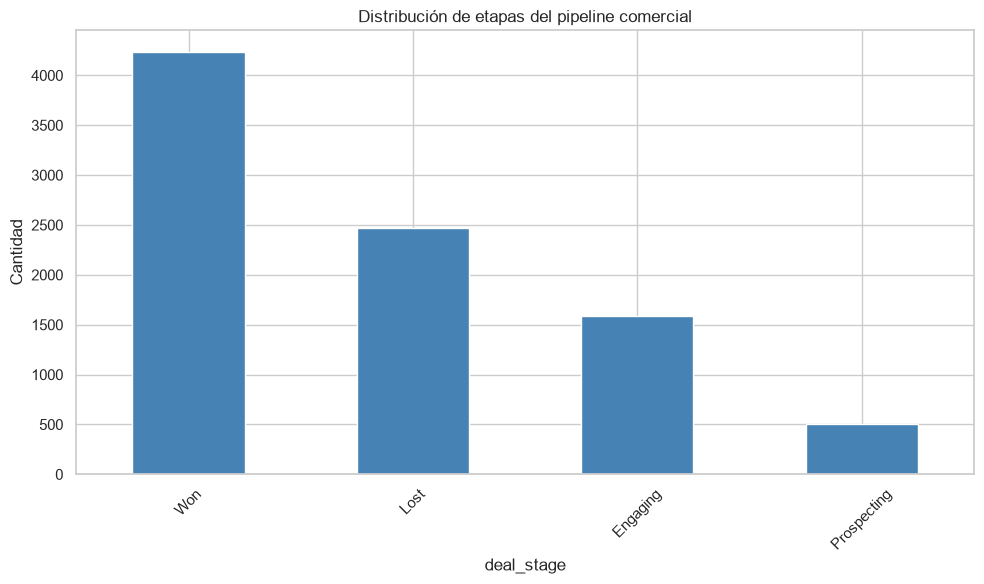

In [6]:
pipeline["deal_stage"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribución de etapas del pipeline comercial")
plt.xlabel("deal_stage"); plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
df = merge_crm_tables(accounts, products, sales_teams, pipeline)

print(f"Dataset enriquecido: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Nulos sales_price tras merge: {df['sales_price'].isnull().sum()}")
df.head()

Dataset enriquecido: 8800 filas x 18 columnas
Nulos sales_price tras merge: 0


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sector,year_established,revenue,employees,office_location,subsidiary_of,series,sales_price,manager,regional_office
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,retail,2001.0,718.62,2448.0,United States,None,GTX,1096,Dustin Brinkmann,Central
1,Z063OYW0,Darcel Schlecht,GTX Pro,Isdom,Won,2016-10-25,2017-03-11,4514.0,medical,2002.0,3178.24,4540.0,United States,None,GTX,4821,Melvin Marxen,Central
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,retail,2001.0,718.62,2448.0,United States,None,MG,55,Melvin Marxen,Central
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,software,1998.0,2714.90,2641.0,United States,Acme Corporation,GTX,550,Dustin Brinkmann,Central
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,services,1982.0,792.46,1299.0,United States,None,GTX,550,Summer Sewald,West


In [8]:
closed = df[df["deal_stage"].isin(["Won", "Lost"])].copy()
closed["won"] = (closed["deal_stage"] == "Won").astype(int)

print("Distribución Won/Lost:")
print(closed["won"].value_counts(normalize=True))
closed.describe(include="all").T

Distribución Won/Lost:
won
1    0.631501
0    0.368499
Name: proportion, dtype: float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
opportunity_id,6711,6711,1C1I7A6R,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_agent,6711,30,Darcel Schlecht,553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product,6711,7,GTX Basic,1436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account,6711,85,Hottechi,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deal_stage,6711,2,Won,4238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engage_date,6711,420,2017-07-17,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
close_date,6711,306,2017-05-22,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
close_value,6711.0,NaN,NaN,NaN,1490.915512,2320.670773,0.0,0.0,472.0,3225.0,30288.0
sector,6711,10,retail,1267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year_established,6711.0,NaN,NaN,NaN,1995.403815,9.190805,1979.0,1988.0,1995.0,2002.0,2017.0


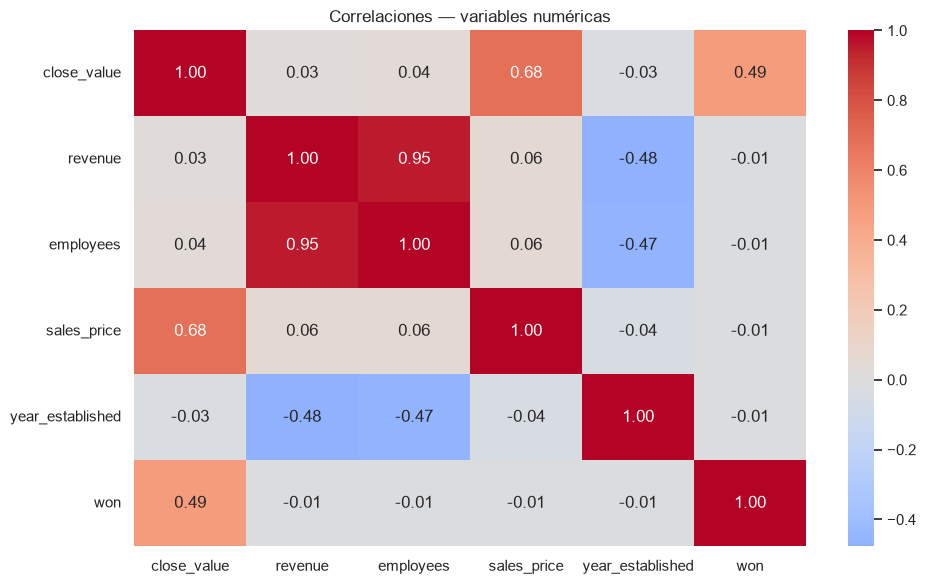

In [9]:
num_cols = [c for c in ["close_value", "revenue", "employees", "sales_price", "year_established"] if c in closed.columns]
corr = closed[num_cols + ["won"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlaciones — variables numéricas")
plt.tight_layout()
plt.show()

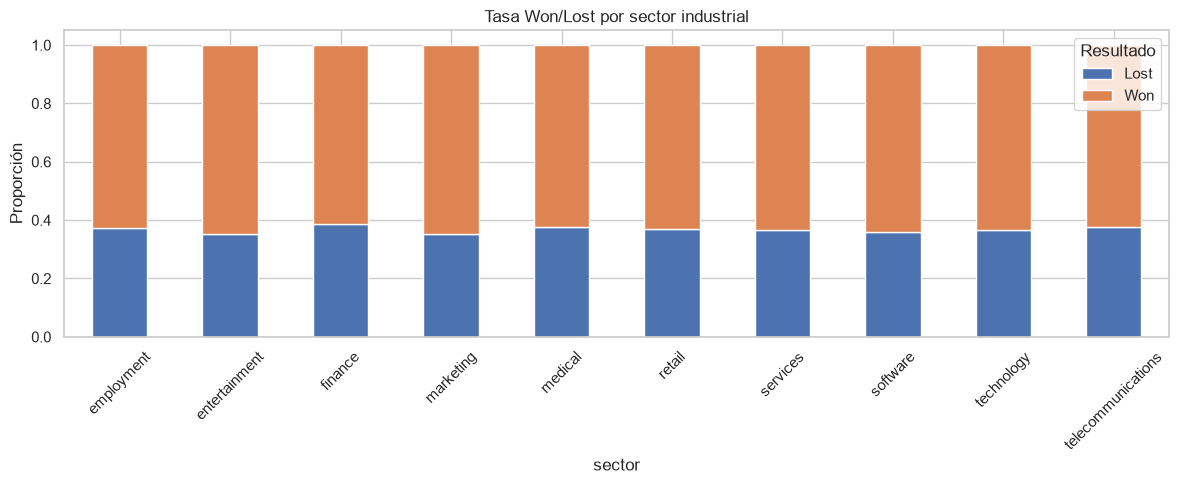

In [10]:
if "sector" in closed.columns:
    pd.crosstab(closed["sector"], closed["deal_stage"], normalize="index").plot(
        kind="bar", stacked=True, figsize=(12, 5)
    )
    plt.title("Tasa Won/Lost por sector industrial")
    plt.ylabel("Proporción"); plt.xticks(rotation=45)
    plt.legend(title="Resultado")
    plt.tight_layout()
    plt.show()